## Objective

### To predict whether a loan applicant is likely to default on a loan using historical loan application data and machine learning classification models.

In [56]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.preprocessing import StandardScaler



In [57]:
df = pd.read_csv("loan_prediction.csv")
df.head()

,Id,Income,Age,Experience,Married/Single,House_Ownership,Car_Ownership,Profession,CITY,STATE,CURRENT_JOB_YRS,CURRENT_HOUSE_YRS,Risk_Flag
0,1,1303834,23,3,single,rented,no,Mechanical_engineer,Rewa,Madhya_Pradesh,3,13,0
1,2,7574516,40,10,single,rented,no,Software_Developer,Parbhani,Maharashtra,9,13,0
2,3,3991815,66,4,married,rented,no,Technical_writer,Alappuzha,Kerala,4,10,0
3,4,6256451,41,2,single,rented,yes,Software_Developer,Bhubaneswar,Odisha,2,12,1
4,5,5768871,47,11,single,rented,no,Civil_servant,Tiruchirappalli[10],Tamil_Nadu,3,14,1


In [58]:
print(df.shape)
print(df.info())

(252000, 13)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 252000 entries, 0 to 251999
Data columns (total 13 columns):
 #   Column             Non-Null Count   Dtype 
---  ------             --------------   ----- 
 0   Id                 252000 non-null  int64 
 1   Income             252000 non-null  int64 
 2   Age                252000 non-null  int64 
 3   Experience         252000 non-null  int64 
 4   Married/Single     252000 non-null  object
 5   House_Ownership    252000 non-null  object
 6   Car_Ownership      252000 non-null  object
 7   Profession         252000 non-null  object
 8   CITY               252000 non-null  object
 9   STATE              252000 non-null  object
 10  CURRENT_JOB_YRS    252000 non-null  int64 
 11  CURRENT_HOUSE_YRS  252000 non-null  int64 
 12  Risk_Flag          252000 non-null  int64 
dtypes: int64(7), object(6)
memory usage: 25.0+ MB
None


In [59]:
df.rename(columns={
    'Married/Single': 'Marital_Status'
}, inplace=True)


In [60]:
df.isnull().sum()


Id                   0
Income               0
Age                  0
Experience           0
Marital_Status       0
House_Ownership      0
Car_Ownership        0
Profession           0
CITY                 0
STATE                0
CURRENT_JOB_YRS      0
CURRENT_HOUSE_YRS    0
Risk_Flag            0
dtype: int64

In [61]:
df.drop('Id', axis=1, inplace=True)



## Exploratory Data Analysis (EDA)

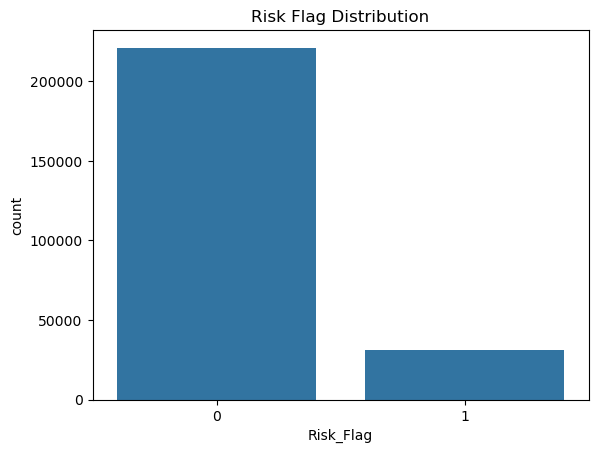

In [62]:
## Credit Risk Distribution
sns.countplot(x='Risk_Flag', data=df)
plt.title("Risk Flag Distribution")
plt.show()


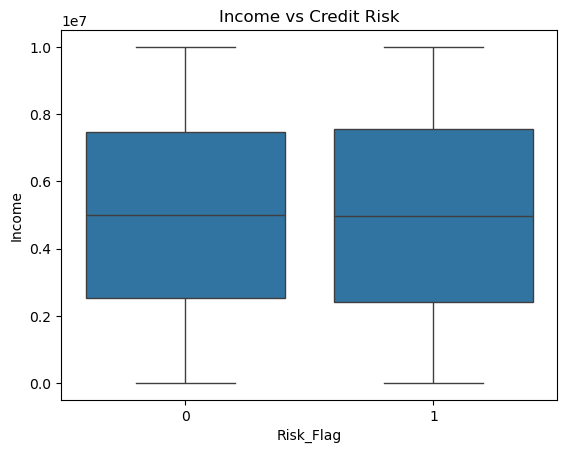

In [63]:
## Income vs Credit Risk
sns.boxplot(x='Risk_Flag', y='Income', data=df)
plt.title("Income vs Credit Risk")
plt.show()


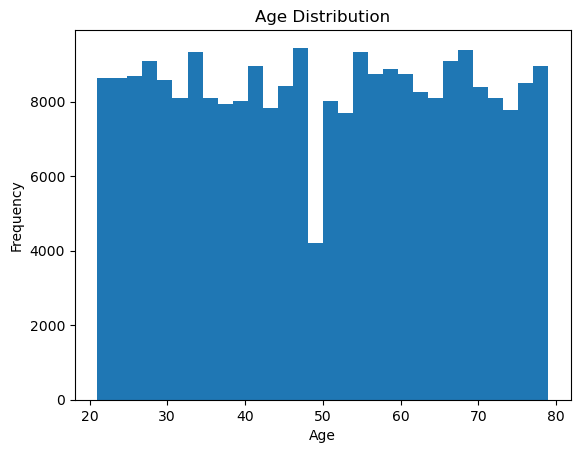

In [64]:
## Age Distribution
plt.hist(df['Age'], bins=30)
plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.show()


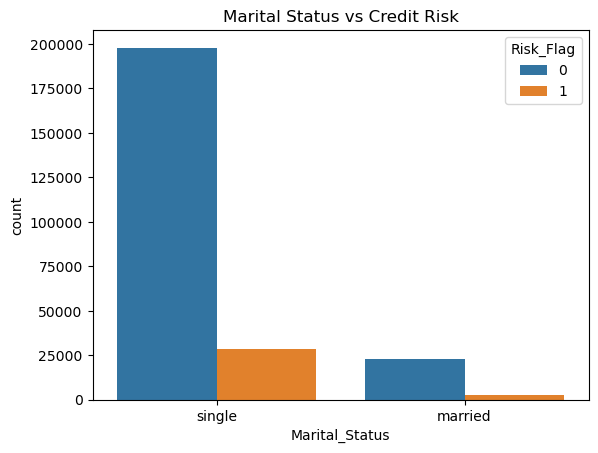

In [65]:
## Marital Status vs Credit Risk
sns.countplot(x='Marital_Status', hue='Risk_Flag', data=df)
plt.title("Marital Status vs Credit Risk")
plt.show()


## Encode Categorical Variables

In [66]:
le = LabelEncoder()

categorical_cols = [
    'Marital_Status',
    'House_Ownership',
    'Car_Ownership',
    'Profession',
    'CITY',
    'STATE'
]

for col in categorical_cols:
    df[col] = le.fit_transform(df[col])


## Feature Selection & Train-Test Split

In [67]:
X = df.drop('Risk_Flag', axis=1)
y = df['Risk_Flag']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)


## Feature Scaling (Required for Logistic Regression)

In [68]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


## Train Classification Models (Logistic Regression)

In [69]:
log_model = LogisticRegression(max_iter=1000)
log_model.fit(X_train_scaled, y_train)

y_pred_log = log_model.predict(X_test_scaled)


In [70]:
## Decision Tree
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train, y_train)

y_pred_dt = dt_model.predict(X_test)


## Model Evaluation

In [71]:
## Logistic Regression Results
print("Logistic Regression Accuracy:",
      accuracy_score(y_test, y_pred_log))

print("Confusion Matrix:\n",
      confusion_matrix(y_test, y_pred_log))


Logistic Regression Accuracy: 0.8770039682539682
Confusion Matrix:
 [[44201     0]
 [ 6199     0]]


In [72]:
## Decision Tree Results
print("Decision Tree Accuracy:",
      accuracy_score(y_test, y_pred_dt))

print("Confusion Matrix:\n",
      confusion_matrix(y_test, y_pred_dt))


Decision Tree Accuracy: 0.8799801587301588
Confusion Matrix:
 [[40822  3379]
 [ 2670  3529]]


In [73]:
# The dataset was clean and contained no missing values.

# EDA highlighted relationships between income, age, marital status, and credit risk.

# Logistic Regression delivered stable and interpretable results.

# Decision Tree captured non-linear relationships.

# The model effectively predicts loan default risk.